In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/card_transdata.csv")

# Preview dataset
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
df.shape

(1000000, 8)

In [14]:
print(df.columns)

Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order', 'fraud'],
      dtype='object')


In [15]:
df["fraud"].value_counts()

,count
fraud,
0.0,912597
1.0,87403


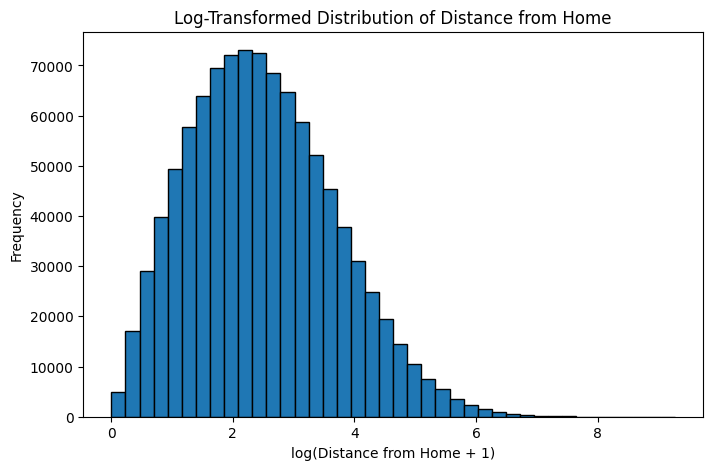

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["distance_from_home"]), bins=40, edgecolor="black")
plt.title("Log-Transformed Distribution of Distance from Home")
plt.xlabel("log(Distance from Home + 1)")
plt.ylabel("Frequency")
plt.show()

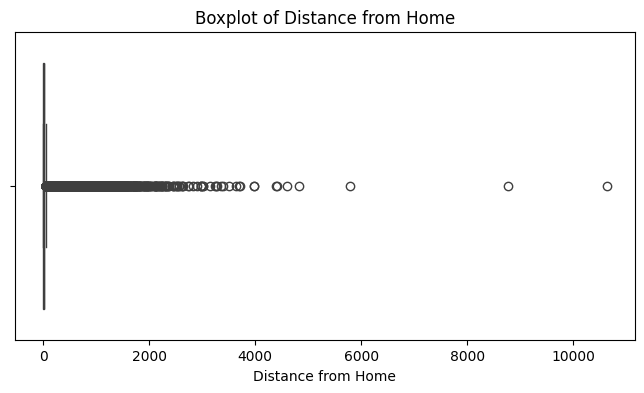

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df["distance_from_home"])
plt.title("Boxplot of Distance from Home")
plt.xlabel("Distance from Home")
plt.show()

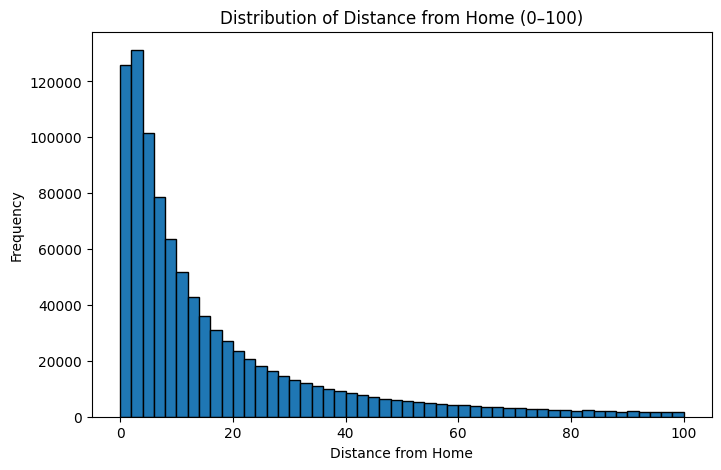

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["distance_from_home"], bins=50, range=(0,100), edgecolor="black")
plt.title("Distribution of Distance from Home (0–100)")
plt.xlabel("Distance from Home")
plt.ylabel("Frequency")
plt.show()

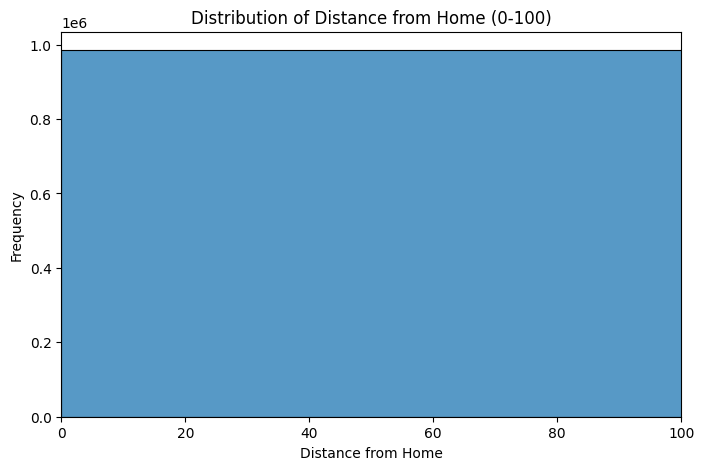

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 1.1: Truncated Histogram Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['distance_from_home'], bins=50, kde=False, edgecolor='black')
plt.xlim(0, 100)
plt.title('Distribution of Distance from Home (0-100)')
plt.xlabel('Distance from Home')
plt.ylabel('Frequency')
plt.show()

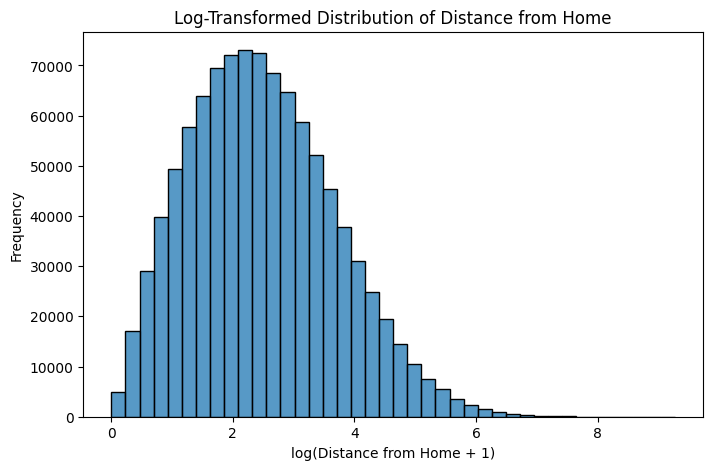

In [20]:
import numpy as np

# Figure 1.3: Log-transformed distribution
plt.figure(figsize=(8, 5))
log_distance = np.log1p(df['distance_from_home'])  # log(x + 1) to handle potential zeros
sns.histplot(log_distance, bins=40, kde=False, edgecolor='black')
plt.title('Log-Transformed Distribution of Distance from Home')
plt.xlabel('log(Distance from Home + 1)')
plt.ylabel('Frequency')
plt.show()

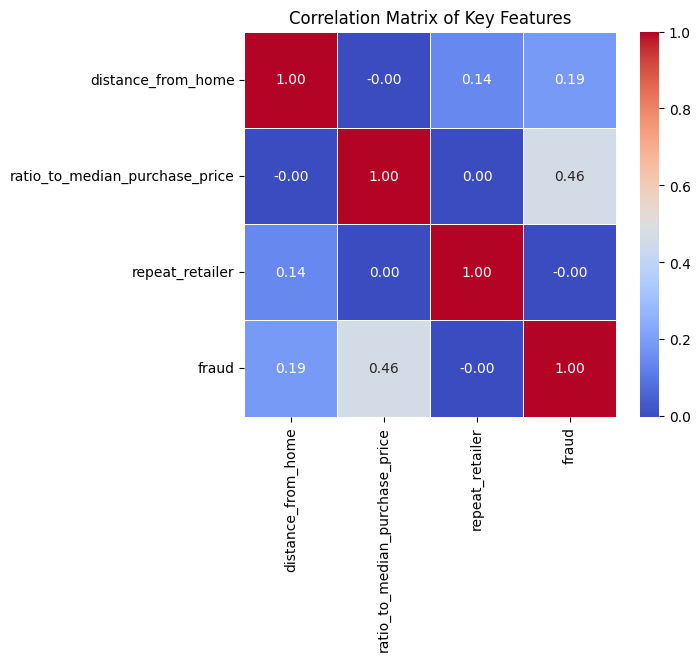

In [21]:
numeric_cols = ['distance_from_home', 'ratio_to_median_purchase_price', 'repeat_retailer', 'fraud']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Features')
plt.show()

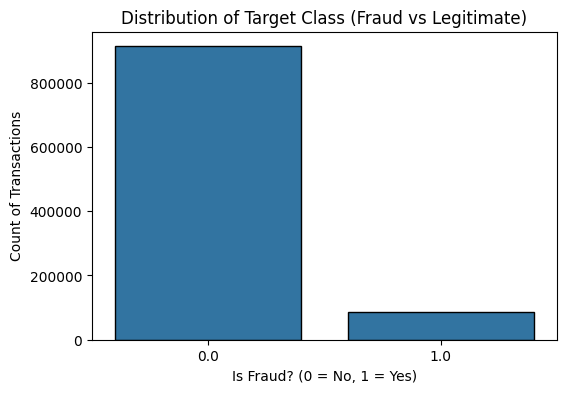

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x='fraud', data=df, edgecolor='black')
plt.title('Distribution of Target Class (Fraud vs Legitimate)')
plt.xlabel('Is Fraud? (0 = No, 1 = Yes)')
plt.ylabel('Count of Transactions')
plt.show()

In [23]:
# Check missing values
missing_values = df.isnull().sum()
print(missing_values)

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64


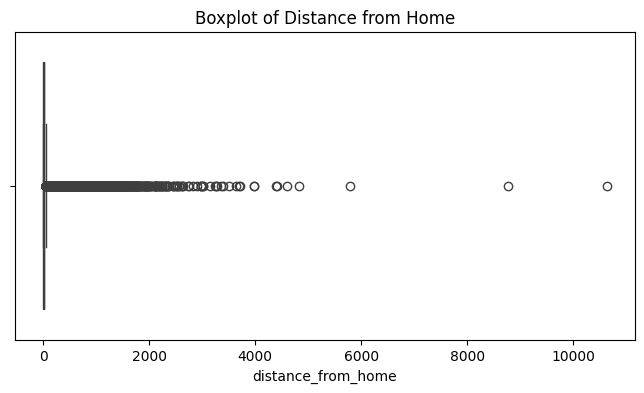

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df["distance_from_home"])
plt.title("Boxplot of Distance from Home")
plt.show()

In [25]:
Q1 = df["distance_from_home"].quantile(0.25)
Q3 = df["distance_from_home"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["distance_from_home"] < lower_bound) |
    (df["distance_from_home"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 103631


In [7]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('card_transdata.csv')


# 1. Feature Engineering Step 1: Log-Transformation
df['log_distance_from_home'] = np.log1p(df['distance_from_home'])
df['log_distance_from_last_transaction'] = np.log1p(df['distance_from_last_transaction'])

# Drop original skewed columns
df = df.drop(columns=['distance_from_home', 'distance_from_last_transaction'])

# 2. Define features and target
X = df.drop(columns=['fraud'])
y = df['fraud']

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define predictor features (X) and target label (y)
X = df.drop(columns=['fraud'])
y = df['fraud']

# FIX: Changed test_split to test_size
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify continuous numeric columns requiring scaling
continuous_cols = ['log_distance_from_home', 'log_distance_from_last_transaction', 'ratio_to_median_purchase_price']

# Initialize and fit the StandardScaler on training data
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# Preview scaled distribution summary
print("\nScaled Training Dataset Preview:")
print(X_train[continuous_cols].head())


Scaled Training Dataset Preview:
        log_distance_from_home  log_distance_from_last_transaction  \
950236               -0.834144                            1.133288   
358251                0.240901                           -0.392220   
597434                0.832779                            0.431097   
296537               -0.060472                           -0.999704   
235768                1.603640                            0.761528   

        ratio_to_median_purchase_price  
950236                       -0.573726  
358251                        0.315170  
597434                       -0.539590  
296537                       -0.526985  
235768                       -0.192063  


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the Baseline Model
# Using a fixed random_state for reproducibility and max_iter to ensure convergence
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the Model (Sprint 2 MVP Execution)
baseline_model.fit(X_train, y_train)

# 3. Generate Predictions on the Evaluation Test Dataset
y_pred_baseline = baseline_model.predict(X_test)

# 4. Extract Operational Evaluation Results for Report Evidence
print("=== Sprint 2: Baseline Model Evaluation Summary ===")
print(classification_report(y_test, y_pred_baseline, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_baseline))

=== Sprint 2: Baseline Model Evaluation Summary ===
              precision    recall  f1-score   support

         0.0     0.9590    0.9911    0.9748    182519
         1.0     0.8578    0.5577    0.6759     17481

    accuracy                         0.9533    200000
   macro avg     0.9084    0.7744    0.8254    200000
weighted avg     0.9502    0.9533    0.9487    200000


=== Confusion Matrix ===
[[180903   1616]
 [  7732   9749]]


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the Improved Ensemble Model (Sprint 3 Innovation)
# Rationale: Random Forest constructs multiple decision trees and merges them together
# to get a more accurate and stable prediction, capturing non-linear feature interactions.
# We utilize class_weight='balanced' to naturally penalize minority class misclassifications.
improved_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Train the Model
improved_model.fit(X_train, y_train)

# 3. Generate Predictions on the Evaluation Test Dataset
y_pred_improved = improved_model.predict(X_test)

# 4. Extract Sprint 3 Evaluation Results for Report Evidence
print("=== Sprint 3: Improved Model (Random Forest) Performance ===")
print(classification_report(y_test, y_pred_improved, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_improved))

=== Sprint 3: Improved Model (Random Forest) Performance ===
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000    182519
         1.0     1.0000    0.9998    0.9999     17481

    accuracy                         1.0000    200000
   macro avg     1.0000    0.9999    0.9999    200000
weighted avg     1.0000    1.0000    1.0000    200000


=== Confusion Matrix ===
[[182519      0]
 [     4  17477]]


In [11]:
import pandas as pd
import numpy as np
import sys

def run_data_validation(file_path):
    print("==================================================")
    print(f"🚀 STARTING AUTOMATED DATA VALIDATION PIPELINE")
    print(f"Target File: {file_path}")
    print("==================================================\n")

    # 1. Ingest Data
    try:
        df = pd.read_csv(file_path)
        print("✅ [PASS] Data Ingestion: File read successfully.")
    except Exception as e:
        print(f"❌ [FAIL] Data Ingestion: Could not read file. Error: {e}")
        sys.exit(1)

    validation_passed = True

    # Check 1: Missing Values Assessment
    missing_count = df.isnull().sum().sum()
    if missing_count == 0:
        print(f"✅ [PASS] Data Completeness: 0 missing values detected.")
    else:
        print(f"❌ [FAIL] Data Completeness: Found {missing_count} missing values!")
        validation_passed = False

    # Check 2: Duplicate Rows Assessment
    duplicate_count = df.duplicated().sum()
    if duplicate_count == 0:
        print(f"✅ [PASS] Data Uniqueness: 0 duplicate rows detected.")
    else:
        print(f"❌ [FAIL] Data Uniqueness: Found {duplicate_count} duplicated rows!")
        validation_passed = False

    # Check 3: Schema and Data Type Consistency
    expected_types = {
        'repeat_retailer': [0.0, 1.0],
        'used_chip': [0.0, 1.0],
        'used_pin_number': [0.0, 1.0],
        'online_order': [0.0, 1.0],
        'fraud': [0.0, 1.0]
    }

    schema_errors = 0
    for col, expected_vals in expected_types.items():
        if col in df.columns:
            invalid_vals = df[~df[col].isin(expected_vals)]
            if not invalid_vals.empty:
                schema_errors += 1
                validation_passed = False

    if schema_errors == 0:
        print("✅ [PASS] Data Schema: Binary categories contain valid flag types (0 or 1).")
    else:
        print(f"❌ [FAIL] Data Schema: Non-binary flags discovered in logical category features.")

    # 4. Final Validation Execution Verdict
    print("\n==================================================")
    if validation_passed:
        print("🎉 STATUS: ALL VALIDATION CHECKS PASSED. DATA SAFE FOR MODELING.")
        print("==================================================")
        return True
    else:
        print("🚨 STATUS: VALIDATION CRASHED. FIX DISCOVERED DATA FLAWS.")
        print("==================================================")
        return False

# Execute validation on your target dataset
if __name__ == "__main__":
    # Ensure this points to your file name path
    run_data_validation('card_transdata.csv')

🚀 STARTING AUTOMATED DATA VALIDATION PIPELINE
Target File: card_transdata.csv

✅ [PASS] Data Ingestion: File read successfully.
✅ [PASS] Data Completeness: 0 missing values detected.
✅ [PASS] Data Uniqueness: 0 duplicate rows detected.
✅ [PASS] Data Schema: Binary categories contain valid flag types (0 or 1).

🎉 STATUS: ALL VALIDATION CHECKS PASSED. DATA SAFE FOR MODELING.


In [1]:
import pandas as pd
import numpy as np
import sys

def run_data_validation(file_path):
    print("==================================================")
    print(f"🚀 STARTING AUTOMATED DATA VALIDATION PIPELINE")
    print(f"Target File: {file_path}")
    print("==================================================\n")

    # 1. Ingest Data Stream
    try:
        df = pd.read_csv(file_path)
        print("✅ [PASS] Data Ingestion: File read successfully.")
    except Exception as e:
        print(f"❌ [FAIL] Data Ingestion: Could not read file. Error: {e}")
        sys.exit(1)

    validation_passed = True

    # Check 1: Data Completeness (Missing Values)
    missing_count = df.isnull().sum().sum()
    if missing_count == 0:
        print(f"✅ [PASS] Data Completeness: 0 missing values detected across features.")
    else:
        print(f"❌ [FAIL] Data Completeness: Found {missing_count} missing values!")
        validation_passed = False

    # Check 2: Data Uniqueness (Duplicate Rows)
    duplicate_count = df.duplicated().sum()
    if duplicate_count == 0:
        print(f"✅ [PASS] Data Uniqueness: 0 duplicate rows detected.")
    else:
        print(f"❌ [FAIL] Data Uniqueness: Found {duplicate_count} duplicated rows!")
        validation_passed = False

    # Check 3: Schema and Value Range Integrity
    expected_ranges = {
        'repeat_retailer': [0.0, 1.0],
        'used_chip': [0.0, 1.0],
        'used_pin_number': [0.0, 1.0],
        'online_order': [0.0, 1.0],
        'fraud': [0.0, 1.0]
    }

    schema_errors = 0
    for col, valid_bounds in expected_ranges.items():
        if col in df.columns:
            invalid_records = df[~df[col].isin(valid_bounds)]
            if not invalid_records.empty:
                schema_errors += 1
                validation_passed = False

    if schema_errors == 0:
        print("✅ [PASS] Data Schema: Binary columns strictly contain valid flag types (0 or 1).")
    else:
        print(f"❌ [FAIL] Data Schema: Out-of-bounds or non-binary types discovered in flag features.")

    # 4. Final Agile Quality Gate Verdict
    print("\n==================================================")
    if validation_passed:
        print("🎉 STATUS: ALL VALIDATION CHECKS PASSED. DATA SAFE FOR MODELING.")
        print("==================================================")
        return True
    else:
        print("🚨 STATUS: VALIDATION CRASHED. BLOCKED DATA SPRINT FLOW.")
        print("==================================================")
        return False

if __name__ == "__main__":
    # Point this to your actual credit card dataset file path
    run_data_validation('card_transdata.csv')

🚀 STARTING AUTOMATED DATA VALIDATION PIPELINE
Target File: card_transdata.csv

✅ [PASS] Data Ingestion: File read successfully.
✅ [PASS] Data Completeness: 0 missing values detected across features.
✅ [PASS] Data Uniqueness: 0 duplicate rows detected.
✅ [PASS] Data Schema: Binary columns strictly contain valid flag types (0 or 1).

🎉 STATUS: ALL VALIDATION CHECKS PASSED. DATA SAFE FOR MODELING.
